In [ ]:
import os
import cv2, tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
image_dir = 'input/train'
train_folders = os.listdir(image_dir)

In [3]:
print(f"Min files in a folder: {min([len([f for f in os.listdir(os.path.join(image_dir, fldr)) if os.path.isfile(os.path.join(image_dir, fldr, f))]) for fldr in train_folders])}")
total_images = sum(
    len([f for f in os.listdir(os.path.join(image_dir, fldr)) if os.path.isfile(os.path.join(image_dir, fldr, f))])
    for fldr in train_folders
)
print(f"Total images: {total_images}")

Min files in a folder: 108
Total images: 7624


In [4]:
Sx = 224
Sy = 224
epocas = 20
train_size = 100
test_size = 20

In [ ]:
def exploreData (folders) :
    plt.figure(figsize=(10,10))
    for i,fol in tqdm.tqdm(enumerate(folders[:25])) :
        plt.subplot(5,5 ,i+1)
        image = os.listdir(os.path.join(image_dir,fol))[0]
        imgPath = os.path.join(image_dir,fol,image)
        img = cv2.imread(imgPath)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        plt.title(fol)
        plt.imshow(imgRGB)
    plt.show()
exploreData(train_folders)

In [5]:
x_test_RGB = []
y_test_RGB = []
x_valid_RGB = []
y_valid_RGB = []
x_train_RGB = []
y_train_RGB = []

random.seed(42)

for folder in tqdm.tqdm(train_folders):
    folder_path = os.path.join(image_dir, folder)
    images_in_folder = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    random.shuffle(images_in_folder)

    valid_images = images_in_folder[:test_size]
    test_images = images_in_folder[test_size:]
    train_images = images_in_folder[train_size:]

    for img_path in test_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_test_RGB.append(imgRGB)
        y_test_RGB.append(folder)

    for img_path in valid_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_valid_RGB.append(imgRGB)
        y_valid_RGB.append(folder)

    for img_path in train_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_train_RGB.append(imgRGB)
        y_train_RGB.append(folder)

x_test_RGB = np.array(x_test_RGB)
x_valid_RGB = np.array(x_valid_RGB)
x_train_RGB = np.array(x_train_RGB)

x_test_RGB = x_test_RGB.astype('float32') / 255.0
x_valid_RGB = x_valid_RGB.astype('float32') / 255.0
x_train_RGB = x_train_RGB.astype('float32') / 255.0

x_test_RGB = x_test_RGB.reshape(-1,Sx,Sy,3)
x_valid_RGB = x_valid_RGB.reshape(-1,Sx,Sy,3)
x_train_RGB = x_train_RGB.reshape(-1,Sx,Sy,3)

df = pd.read_csv('input/cards.csv')
category_labels = df.labels.value_counts().index
categories = {}
for index,cat in enumerate(category_labels) :
  categories[cat]=index

y_train_RGB = [categories[i] for i in y_train_RGB]
y_valid_RGB = [categories[i] for i in y_valid_RGB]
y_test_RGB = [categories[i] for i in y_test_RGB]

y_train_RGB = to_categorical(y_train_RGB)
y_valid_RGB = to_categorical(y_valid_RGB)
y_test_RGB = to_categorical(y_test_RGB)

100%|██████████| 53/53 [00:04<00:00, 12.92it/s]


In [6]:
x_test_ByN = []
y_test_ByN = []
x_valid_ByN = []
y_valid_ByN = []
x_train_ByN = []
y_train_ByN = []

random.seed(42)

for folder in tqdm.tqdm(train_folders):
    folder_path = os.path.join(image_dir, folder)
    images_in_folder = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    random.shuffle(images_in_folder)

    valid_images = images_in_folder[:test_size]
    test_images = images_in_folder[test_size:]
    train_images = images_in_folder[train_size:]

    for img_path in test_images:
        img = cv2.imread(img_path)
        imgByN = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
        imgByN = cv2.resize(imgByN, (Sx,Sy))
        x_test_ByN.append(imgByN)
        y_test_ByN.append(folder)

    for img_path in valid_images:
        img = cv2.imread(img_path)
        imgByN = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
        imgByN = cv2.resize(imgByN, (Sx,Sy))
        x_valid_ByN.append(imgByN)
        y_valid_ByN.append(folder)

    for img_path in train_images:
        img = cv2.imread(img_path)
        imgByN = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
        imgByN = cv2.resize(imgByN, (Sx,Sy))
        x_train_ByN.append(imgByN)
        y_train_ByN.append(folder)

x_test_ByN = np.array(x_test_ByN)
x_valid_ByN = np.array(x_valid_ByN)
x_train_ByN = np.array(x_train_ByN)

x_test_ByN = x_test_ByN.astype('float32') / 255.0
x_valid_ByN = x_valid_ByN.astype('float32') / 255.0
x_train_ByN = x_train_ByN.astype('float32') / 255.0

x_test_ByN = x_test_ByN.reshape(-1,Sx,Sy,1)
x_valid_ByN = x_valid_ByN.reshape(-1,Sx,Sy,1)
x_train_ByN = x_train_ByN.reshape(-1,Sx,Sy,1)

df = pd.read_csv('input/cards.csv')
category_labels = df.labels.value_counts().index
categories = {}
for index,cat in enumerate(category_labels) :
  categories[cat]=index

y_train_ByN = [categories[i] for i in y_train_ByN]
y_valid_ByN = [categories[i] for i in y_valid_ByN]
y_test_ByN = [categories[i] for i in y_test_ByN]

y_train_ByN = to_categorical(y_train_ByN)
y_valid_ByN = to_categorical(y_valid_ByN)
y_test_ByN = to_categorical(y_test_ByN)

100%|██████████| 53/53 [00:04<00:00, 12.46it/s]


In [ ]:
modelo_1 = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(32 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_1.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_1_metrics = modelo_1.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = epocas)

In [ ]:
modelo_1.evaluate(x_test_RGB, y_test_RGB)

In [ ]:
plt.plot(modelo_1_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_1_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
modelo_1_ByN = Sequential([
    Input(shape=(Sx,Sy,1)),
    Conv2D(32 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_1_ByN.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_1_ByN_metrics = modelo_1_ByN.fit(x_train_ByN,y_train_ByN,validation_data= (x_valid_ByN,y_valid_ByN), epochs = epocas)

Epoch 1/20
73/73 [==============================] - 5s 59ms/step - loss: 5.9190 - accuracy: 0.0306 - val_loss: 3.9467 - val_accuracy: 0.0217
Epoch 2/20
73/73 [==============================] - 4s 55ms/step - loss: 3.8349 - accuracy: 0.0353 - val_loss: 3.8828 - val_accuracy: 0.0179
Epoch 3/20
73/73 [==============================] - 4s 52ms/step - loss: 3.6941 - accuracy: 0.0456 - val_loss: 3.8328 - val_accuracy: 0.0349
Epoch 4/20
73/73 [==============================] - 4s 51ms/step - loss: 3.5827 - accuracy: 0.0676 - val_loss: 3.8116 - val_accuracy: 0.0406
Epoch 5/20
73/73 [==============================] - 4s 52ms/step - loss: 3.4473 - accuracy: 0.0826 - val_loss: 3.8074 - val_accuracy: 0.0528
Epoch 6/20
73/73 [==============================] - 4s 52ms/step - loss: 3.2244 - accuracy: 0.1235 - val_loss: 3.7346 - val_accuracy: 0.0745
Epoch 7/20
73/73 [==============================] - 5s 66ms/step - loss: 2.8646 - accuracy: 0.1988 - val_loss: 3.6285 - val_accuracy: 0.0934
Epoch 8/20
73

In [13]:
modelo_1_ByN.evaluate(x_test_ByN, y_test_ByN)

206/206 [==============================] - 3s 12ms/step - loss: 4.2062 - accuracy: 0.4689


[4.206230640411377, 0.46892139315605164]

In [ ]:
plt.plot(modelo_1_ByN_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_1_ByN_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
modelo_VGG = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(64 , (3,3) , activation='relu'),
    Conv2D(64 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128 , (3,3) , activation='relu'),
    Conv2D(128 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation='relu'),
    Conv2D(256 , (3,3) , activation='relu'),
    Conv2D(256 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512 , (3,3) , activation='relu'),
    Conv2D(512 , (3,3) , activation='relu'),
    Conv2D(512 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_VGG.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_VGG_metrics = modelo_VGG.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = 3)

In [8]:
modelo_VGG = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(64 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_VGG.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_VGG_metrics = modelo_VGG.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = epocas)

Epoch 1/20
73/73 [==============================] - 27s 266ms/step - loss: 3.9152 - accuracy: 0.0417 - val_loss: 3.8212 - val_accuracy: 0.0547
Epoch 2/20
73/73 [==============================] - 14s 192ms/step - loss: 3.2203 - accuracy: 0.1803 - val_loss: 3.2171 - val_accuracy: 0.1575
Epoch 3/20
73/73 [==============================] - 14s 192ms/step - loss: 2.6168 - accuracy: 0.2814 - val_loss: 2.9124 - val_accuracy: 0.2613
Epoch 4/20
73/73 [==============================] - 14s 192ms/step - loss: 2.0738 - accuracy: 0.4036 - val_loss: 2.4429 - val_accuracy: 0.3189
Epoch 5/20
73/73 [==============================] - 14s 193ms/step - loss: 1.5408 - accuracy: 0.5448 - val_loss: 2.3621 - val_accuracy: 0.4057
Epoch 6/20
73/73 [==============================] - 14s 193ms/step - loss: 1.1405 - accuracy: 0.6571 - val_loss: 2.5189 - val_accuracy: 0.4264
Epoch 7/20
73/73 [==============================] - 14s 193ms/step - loss: 0.7198 - accuracy: 0.7780 - val_loss: 3.0824 - val_accuracy: 0.4349

In [9]:
modelo_VGG.evaluate(x_test_RGB, y_test_RGB)

206/206 [==============================] - 7s 36ms/step - loss: 2.8723 - accuracy: 0.6839


[2.8723340034484863, 0.6838817596435547]

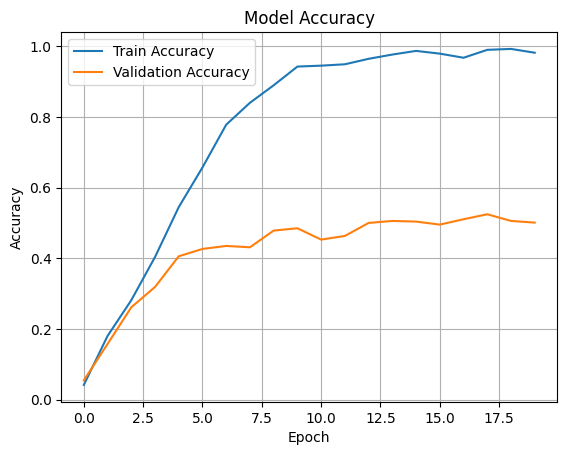

In [10]:
plt.plot(modelo_VGG_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_VGG_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
modelo_VGG_ByN = Sequential([
    Input(shape=(Sx,Sy,1)),
    Conv2D(64 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_VGG_ByN.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_VGG_ByN_metrics = modelo_VGG_ByN.fit(x_train_ByN,y_train_ByN,validation_data= (x_valid_ByN,y_valid_ByN), epochs = epocas)

Epoch 1/20
73/73 [==============================] - 38s 348ms/step - loss: 3.9557 - accuracy: 0.0250 - val_loss: 4.0322 - val_accuracy: 0.0189
Epoch 2/20
73/73 [==============================] - 20s 273ms/step - loss: 3.7530 - accuracy: 0.0654 - val_loss: 3.6386 - val_accuracy: 0.1085
Epoch 3/20
73/73 [==============================] - 21s 284ms/step - loss: 2.9548 - accuracy: 0.2225 - val_loss: 3.0788 - val_accuracy: 0.1830
Epoch 4/20
73/73 [==============================] - 26s 354ms/step - loss: 2.3502 - accuracy: 0.3477 - val_loss: 2.5667 - val_accuracy: 0.2943
Epoch 5/20
73/73 [==============================] - 18s 253ms/step - loss: 1.8645 - accuracy: 0.4738 - val_loss: 2.2258 - val_accuracy: 0.3972
Epoch 6/20
73/73 [==============================] - 19s 257ms/step - loss: 1.4159 - accuracy: 0.5968 - val_loss: 2.3480 - val_accuracy: 0.4387
Epoch 7/20
73/73 [==============================] - 19s 267ms/step - loss: 1.0740 - accuracy: 0.6867 - val_loss: 2.2754 - val_accuracy: 0.4811

In [9]:
modelo_VGG_ByN.evaluate(x_test_ByN, y_test_ByN)

206/206 [==============================] - 14s 66ms/step - loss: 3.7065 - accuracy: 0.7110


[3.706519365310669, 0.7109993696212769]

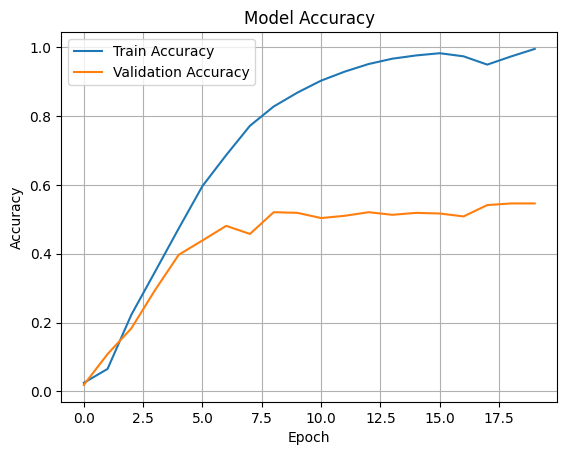

In [11]:
plt.plot(modelo_VGG_ByN_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_VGG_ByN_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()